<a href="https://www.kaggle.com/code/navneet0094/hog-lbp-sift-on-ckplus?scriptVersionId=312760896" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [48]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S071_001_00000012.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S082_001_00000013.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S116_001_00000013.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S097_001_00000020.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S085_003_00000013.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S127_001_00000015.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S085_003_00000011.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S107_001_00000008.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S138_004_00000013.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S068_003_00000013.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S126_004_00000010.png

In [70]:
import os
import cv2
import numpy as np
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [71]:
data = []
labels = []

dataset_path = "/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48"

for label, emotion in enumerate(os.listdir(dataset_path)):
    emotion_path = os.path.join(dataset_path, emotion)

    for img_name in os.listdir(emotion_path):
        img_path = os.path.join(emotion_path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (48,48))

        data.append(img)
        labels.append(label)

data = np.array(data)
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels:", np.unique(labels))

Data shape: (750, 48, 48)
Labels: [0 1 2 3 4]


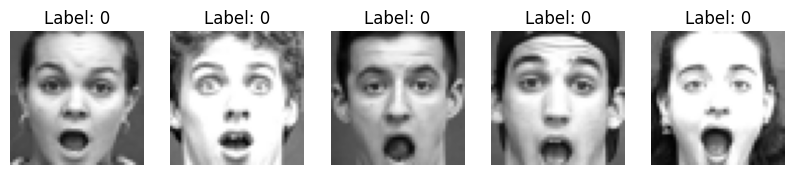

In [72]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(data[i], cmap='gray')
    plt.title(f"Label: {labels[i]}")
    plt.axis('off')

plt.show()

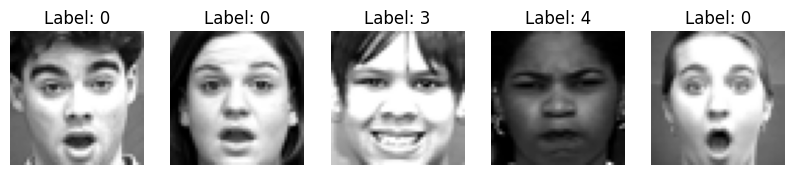

In [73]:
import random

plt.figure(figsize=(10,5))

for i in range(5):
    idx = random.randint(0, len(data)-1)
    plt.subplot(1,5,i+1)
    plt.imshow(data[idx], cmap='gray')
    plt.title(f"Label: {labels[idx]}")
    plt.axis('off')

plt.show()

In [74]:
# HOG
from skimage.feature import hog

X_hog = []

for img in data:
    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2)
    )
    X_hog.append(features)

X_hog = np.array(X_hog)

print("HOG feature shape:", X_hog.shape)

HOG feature shape: (750, 900)


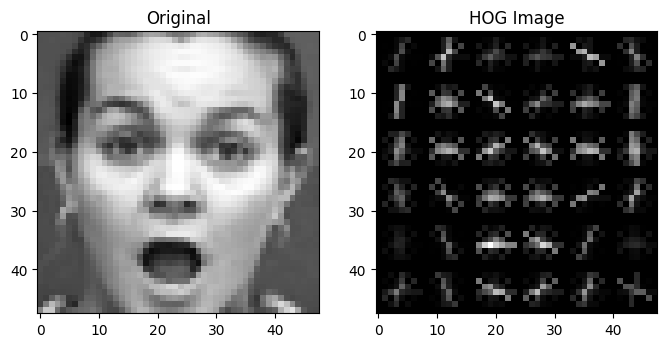

In [75]:
# HOG vis
sample_img = data[0]

features, hog_image = hog(
    sample_img,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True
)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(sample_img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap='gray')
plt.title("HOG Image")

plt.show()

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import time

In [86]:
X_scaled = StandardScaler().fit_transform(X_hog)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, labels, test_size=0.2, random_state=42
)

start = time.time()

model = SVC(kernel='linear')
model.fit(X_train, y_train)

end = time.time()

y_pred = model.predict(X_test)

hog_acc = accuracy_score(y_test, y_pred)
hog_time = end - start

print("HOG Accuracy:", hog_acc)
print("HOG Time:", hog_time)

HOG Accuracy: 0.98
HOG Time: 0.07065033912658691


In [87]:
emotion_names = os.listdir(dataset_path)
print(classification_report(y_test, y_pred, target_names=emotion_names))

              precision    recall  f1-score   support

    surprise       1.00      1.00      1.00        52
        fear       0.82      1.00      0.90        14
     sadness       1.00      1.00      1.00        20
       happy       1.00      0.92      0.96        36
       anger       1.00      1.00      1.00        28

    accuracy                           0.98       150
   macro avg       0.96      0.98      0.97       150
weighted avg       0.98      0.98      0.98       150



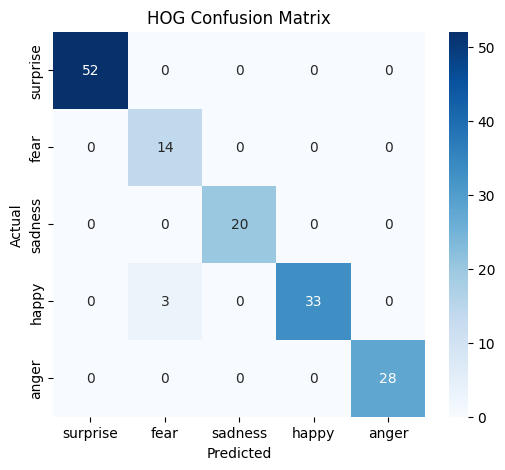

In [88]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names,
            yticklabels=emotion_names)

plt.title("HOG Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [89]:
# SIFT
sift = cv2.SIFT_create()

X_sift = []

for img in data:
    img = img.astype('uint8')

    _, des = sift.detectAndCompute(img, None)

    if des is None:
        des = np.zeros(500)
    else:
        des = des.flatten()
        if len(des) > 500:
            des = des[:500]
        else:
            des = np.pad(des, (0, 500-len(des)))

    X_sift.append(des)

X_sift = np.array(X_sift)

print("SIFT feature shape:", X_sift.shape)

SIFT feature shape: (750, 500)


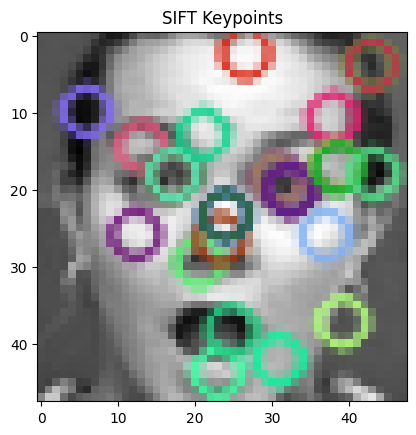

In [90]:
# SIFT vis

sample_img = data[0].astype('uint8')
kp, _ = sift.detectAndCompute(sample_img, None)

img_kp = cv2.drawKeypoints(sample_img, kp, None)

plt.imshow(img_kp, cmap='gray')
plt.title("SIFT Keypoints")
plt.show()

In [91]:
X_scaled = StandardScaler().fit_transform(X_sift)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, labels, test_size=0.2, random_state=42,shuffle=False
)

start = time.time()

model = SVC(kernel='linear')
model.fit(X_train, y_train)

end = time.time()

y_pred1 = model.predict(X_test)

sift_acc = accuracy_score(y_test, y_pred1)
sift_time = end - start

print("SIFT Accuracy:", sift_acc)
print("SIFT Time:", sift_time)

SIFT Accuracy: 0.05333333333333334
SIFT Time: 0.1047663688659668


In [92]:
emotion_names = os.listdir(dataset_path)
print(classification_report(y_test, y_pred1, target_names=emotion_names))

              precision    recall  f1-score   support

    surprise       0.00      0.00      0.00         0
        fear       0.00      0.00      0.00         0
     sadness       0.00      0.00      0.00         0
       happy       0.15      0.53      0.23        15
       anger       0.00      0.00      0.00       135

    accuracy                           0.05       150
   macro avg       0.03      0.11      0.05       150
weighted avg       0.01      0.05      0.02       150



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

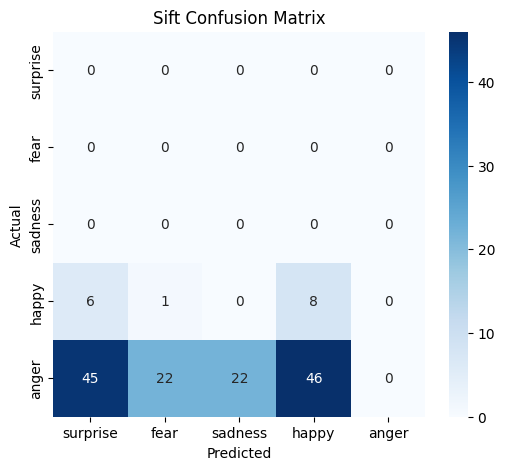

In [93]:
cm = confusion_matrix(y_test, y_pred1)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names,
            yticklabels=emotion_names)

plt.title("Sift Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [94]:
# LBP
from skimage.feature import local_binary_pattern

X_lbp = []

for img in data:
    lbp = local_binary_pattern(img, 8, 1, method="uniform")
    # hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0,10))
    hist, _ = np.histogram(lbp.ravel(), bins=256, range=(0,256))
    X_lbp.append(hist)

X_lbp = np.array(X_lbp)

print("LBP feature shape:", X_lbp.shape)

LBP feature shape: (750, 256)


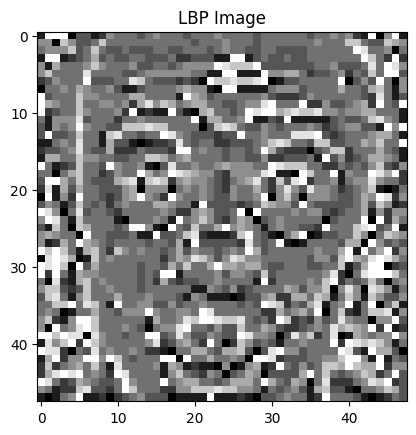

In [95]:
# lbp vis
sample_img = data[0]

lbp = local_binary_pattern(sample_img, 8, 1, method="uniform")

plt.imshow(lbp, cmap='gray')
plt.title("LBP Image")
plt.show()

In [96]:
X_scaled = StandardScaler().fit_transform(X_lbp)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, labels, test_size=0.2, random_state=42 ,shuffle =True
)

start = time.time()

model = SVC(kernel='linear')
model.fit(X_train, y_train)

end = time.time()

y_pred2 = model.predict(X_test)

lbp_acc = accuracy_score(y_test, y_pred2)
lbp_time = end - start

print("LBP Accuracy:", lbp_acc)
print("LBP Time:", lbp_time)

LBP Accuracy: 0.44
LBP Time: 0.06369924545288086


In [97]:
emotion_names = os.listdir(dataset_path)
print(classification_report(y_test, y_pred2, target_names=emotion_names))

              precision    recall  f1-score   support

    surprise       0.47      0.69      0.56        52
        fear       0.00      0.00      0.00        14
     sadness       0.00      0.00      0.00        20
       happy       0.44      0.61      0.51        36
       anger       0.35      0.29      0.31        28

    accuracy                           0.44       150
   macro avg       0.25      0.32      0.28       150
weighted avg       0.33      0.44      0.37       150



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


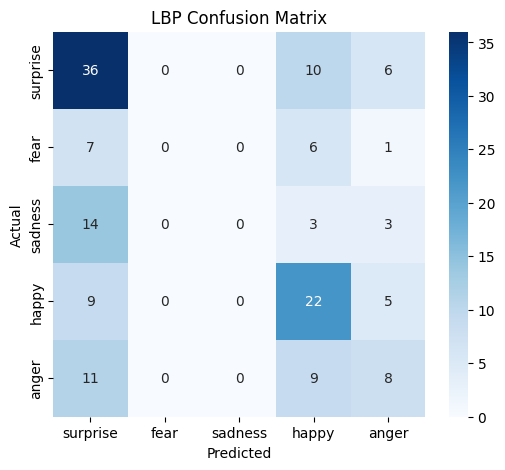

In [98]:
cm = confusion_matrix(y_test, y_pred2)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names,
            yticklabels=emotion_names)

plt.title("LBP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [99]:
plt.figure()

bars = plt.bar(methods, accuracy)

# add numbers on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             round(yval, 3),  # show 3 decimal places
             ha='center', va='bottom')

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

NameError: name 'methods' is not defined

<Figure size 640x480 with 0 Axes>

In [100]:
plt.figure()

bars = plt.bar(methods, time_taken)

# add numbers on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             round(yval, 3),
             ha='center', va='bottom')

plt.title("Time Comparison")
plt.ylabel("Time (seconds)")
plt.show()

NameError: name 'methods' is not defined

<Figure size 640x480 with 0 Axes>

In [ ]:
# import pandas as pd

# df = pd.DataFrame({
#     'Method': methods,
#     'Accuracy': accuracy,
#     'Time (s)': time_taken
# })

# print(df)
import pandas as pd

df = pd.DataFrame({
    'Method': methods,
    'Accuracy (%)': [round(acc * 100, 2) for acc in accuracy],
    'Time (s)': [round(t, 2) for t in time_taken]
})

print(df)

In [ ]:

surf = cv2.xfeatures2d.SURF_create()


X_surf = []

if surf is not None:
    for img in data:
        img = img.astype('uint8')

        _, des = surf.detectAndCompute(img, None)

        if des is None:
            des = np.zeros(500)
        else:
            des = des.flatten()
            if len(des) > 500:
                des = des[:500]
            else:
                des = np.pad(des, (0, 500-len(des)))

        X_surf.append(des)

    X_surf = np.array(X_surf)

    print("SURF feature shape:", X_surf.shape)